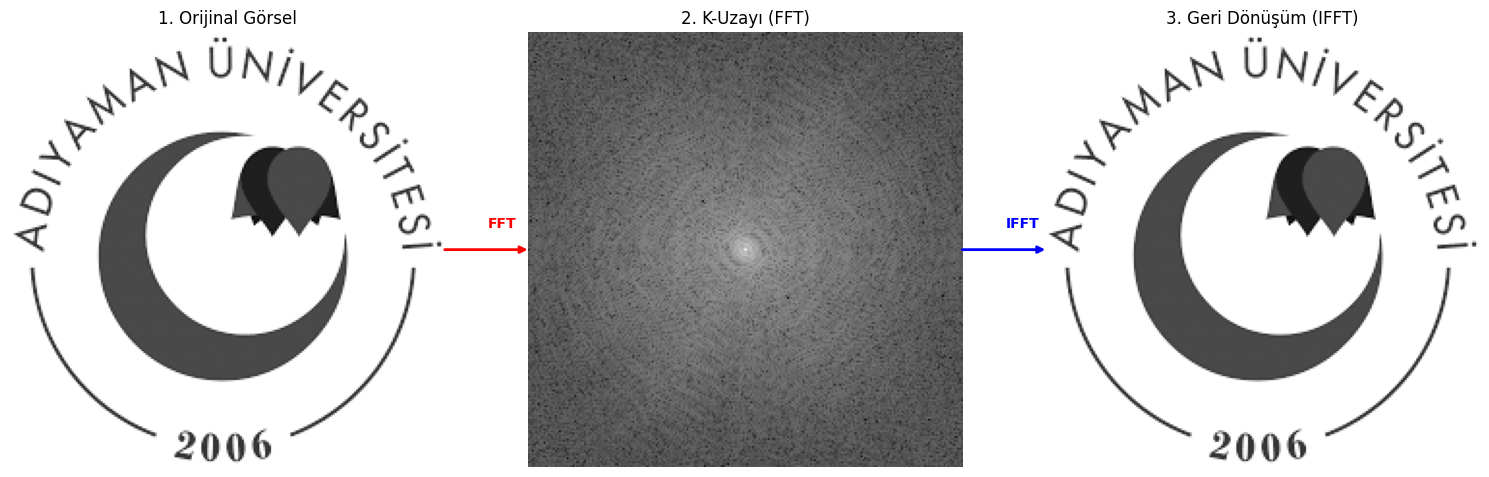

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch 

file_path = "Desktop/MedikalGoruntuIsleme/Hafta 2/adyu.png"
img = cv2.imread(file_path, 0)

if img is not None:
    # --- İLERİ DÖNÜŞÜM (FFT) ---
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))

    # --- TERS DÖNÜŞÜM (IFFT) ---
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.abs(np.fft.ifft2(f_ishift))

    # --- GÖRSELLEŞTİRME VE OKLAR ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    ax1.imshow(img, cmap='gray')
    ax1.set_title('1. Orijinal Görsel')
    
    ax2.imshow(magnitude_spectrum, cmap='gray')
    ax2.set_title('2. K-Uzayı (FFT)')
    
    ax3.imshow(img_back, cmap='gray')
    ax3.set_title('3. Geri Dönüşüm (IFFT)')

    for ax in [ax1, ax2, ax3]:
        ax.axis('off')

    # --- OKLARIN EKLENMESİ ---
    con1 = ConnectionPatch(xyA=(1, 0.5), xyB=(0, 0.5), coordsA="axes fraction", coordsB="axes fraction",
                          axesA=ax1, axesB=ax2, arrowstyle="-|>", color="red", lw=2)
    fig.add_artist(con1)
    ax1.text(1.1, 0.55, 'FFT', transform=ax1.transAxes, color='red', fontweight='bold')

    con2 = ConnectionPatch(xyA=(1, 0.5), xyB=(0, 0.5), coordsA="axes fraction", coordsB="axes fraction",
                          axesA=ax2, axesB=ax3, arrowstyle="-|>", color="blue", lw=2)
    fig.add_artist(con2)
    ax2.text(1.1, 0.55, 'IFFT', transform=ax2.transAxes, color='blue', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Hata: Görsel okunurken bir sorun oluştu.")